In [1]:
import matplotlib.pylab as plt
import numpy as np
import os
import sys
from pathlib import Path
from hdf5storage import loadmat, savemat
from scipy import signal

dataset_path = '/home/zhang/zxc/STFT_3DDL/DATASETS/raw_data/DAS1K/'

def get_class_names(directory_path):
    # 转换为Path对象
    directory = Path(directory_path)
    # 确保路径存在且为目录
    if not directory.is_dir():
        raise ValueError(f"{directory_path} 不是一个有效的目录路径")
    
    # 创建一个集合来存储类别名，避免重复
    category_names = set()
    
    # 遍历主文件夹下的所有子文件夹
    for subfolder in directory.iterdir():
        if subfolder.is_dir():  # 检查是否为子文件夹
            # 遍历子文件夹中的文件
            category_names.add(subfolder.stem)
    
    # 返回类别名列表
    return list(category_names)

def get_iterfile_names(directory_path):
    # 转换为Path对象
    directory = Path(directory_path)
    # 确保路径存在且为目录
    if not directory.is_dir():
        raise ValueError(f"{directory_path} 不是一个有效的目录路径")
    
    # 创建一个集合来存储文件名，避免重复
    file_names = set()
    
    # 遍历主文件夹下的所有子文件夹
    for subfolder in directory.iterdir():
        if subfolder.is_file():  # 检查是否为子文件
            file_names.add(subfolder.stem)
    
    # 返回文件名列表
    return list(file_names)

def read_raw_signal_file(dataset_path, class_name, iterfile_name):
    iterfile_path = Path(dataset_path) / class_name / f"{iterfile_name}.mat"
    # mat = loadmat('/home/zhang/zxc/STFT_3DDL/DATASETS/raw_data/DAS1K/CARHORN/carhorn1.mat')
    mat = loadmat(str(iterfile_path))
    phase = mat[iterfile_name][0]
    intensity = mat[iterfile_name][1]
    return phase, intensity

def print_signal(signal, frequency):
    taxis = np.arange(len(signal))/frequency
    plt.figure(figsize=(15, 15))
    plt.plot(taxis, signal)

SHOVELING
shoveling41


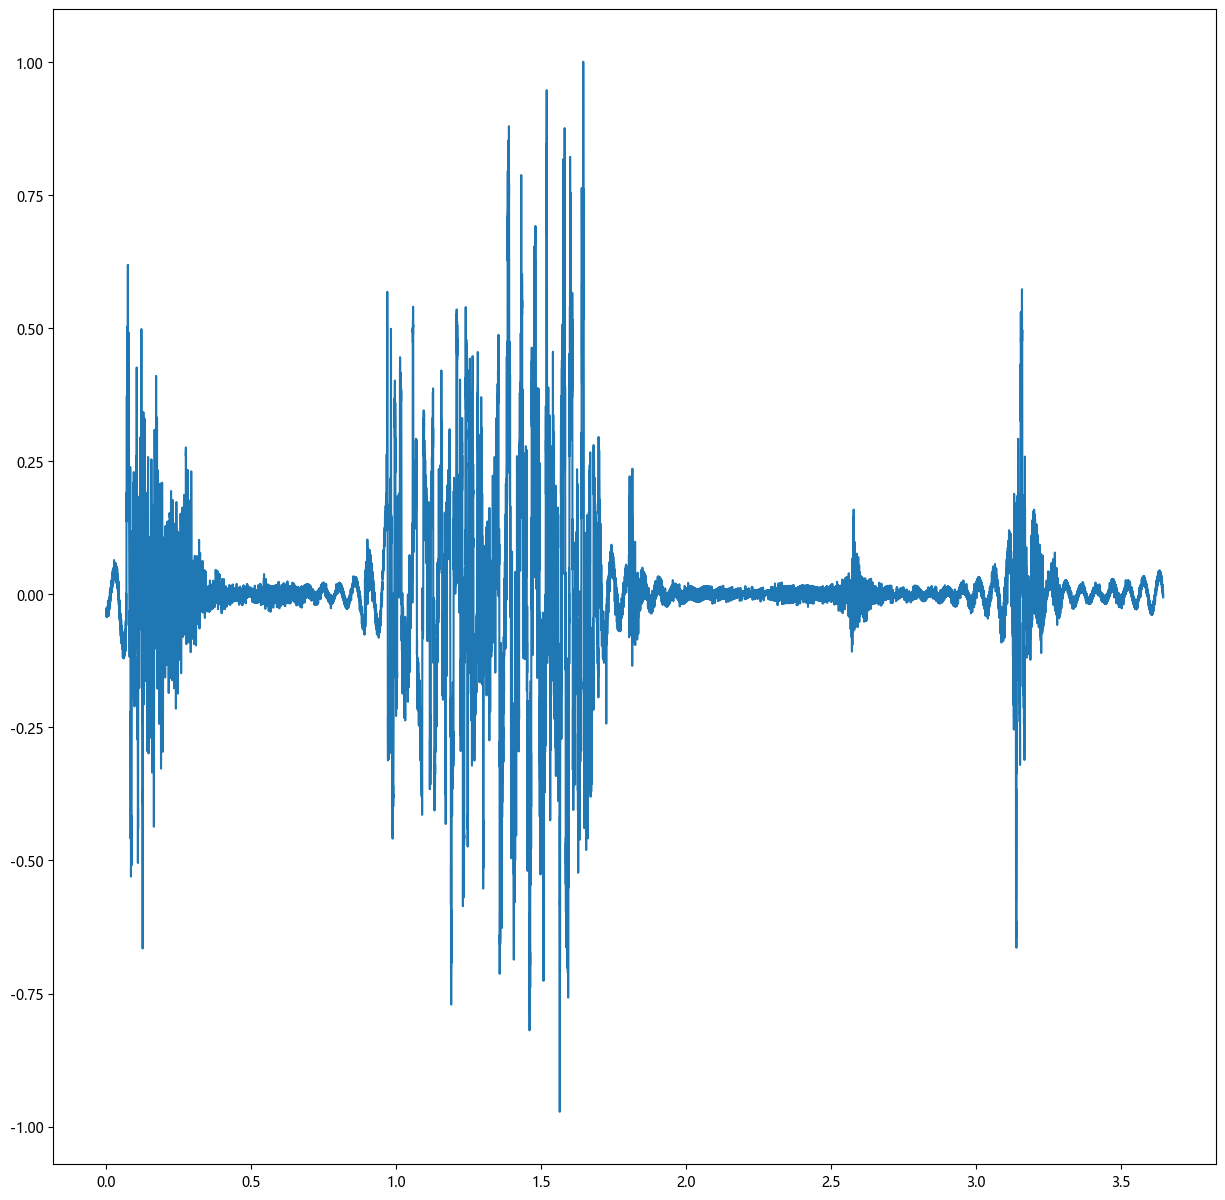

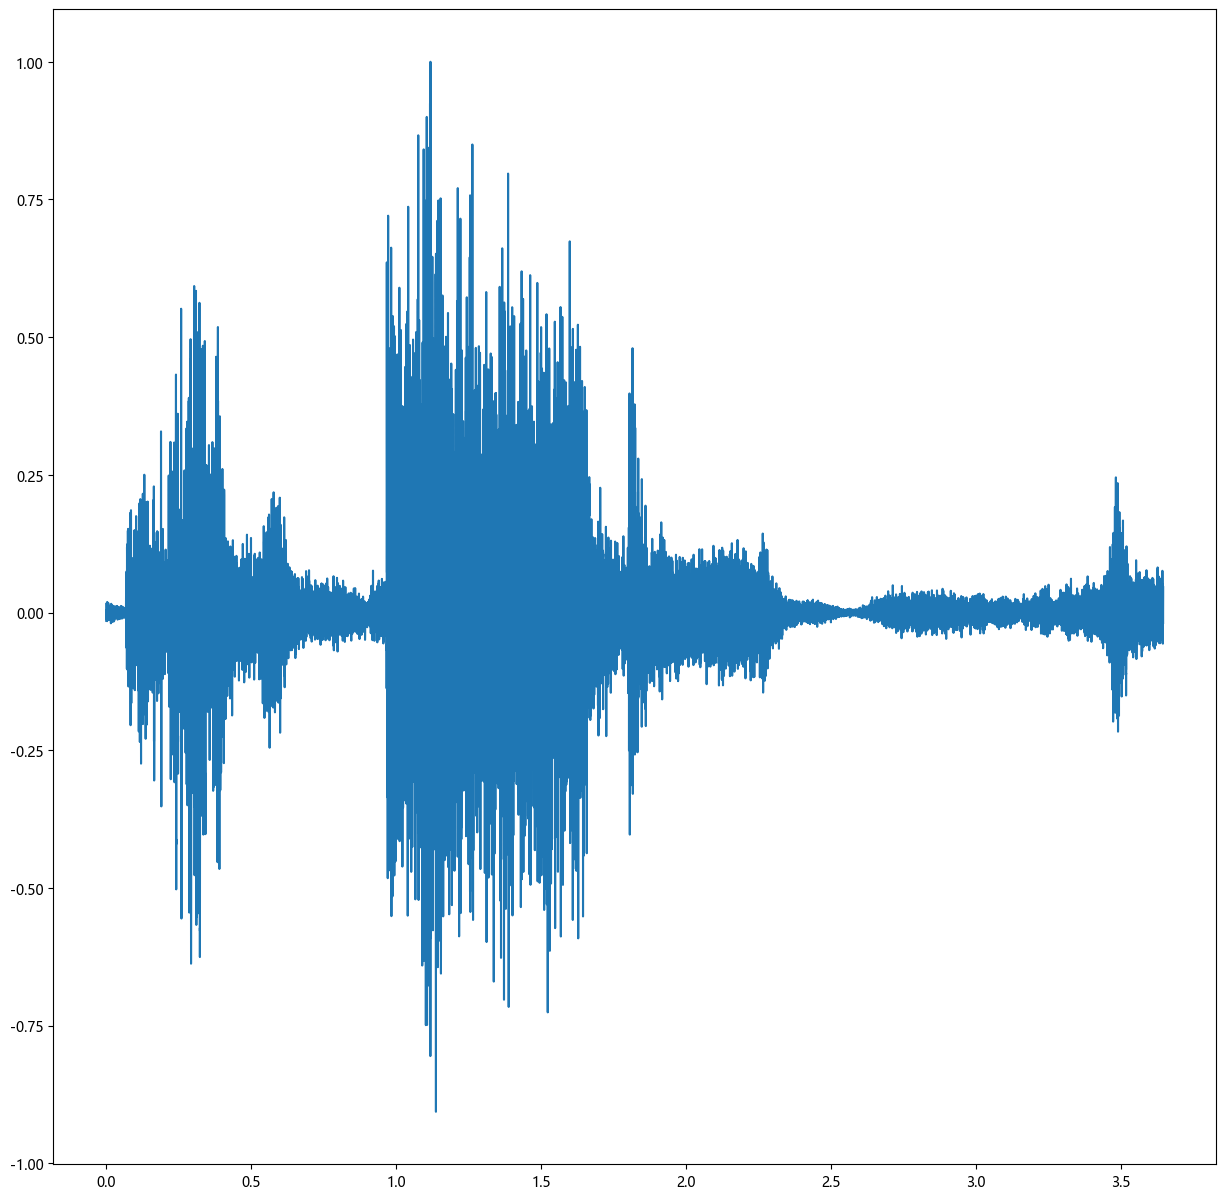

In [2]:
class_names = get_class_names(dataset_path)
class_names_0 = class_names[0]

iterfile_names = get_iterfile_names(dataset_path+class_names_0)
iterfile_names_0 = iterfile_names[0]

phase, intensity = read_raw_signal_file(dataset_path, class_names_0, iterfile_names_0)

FREQUENCY = 10000
print(class_names_0)
print(iterfile_names_0)
print_signal(phase, FREQUENCY)
print_signal(intensity, FREQUENCY)

In [4]:
# ========== 增强方法 ==========
def time_shift(signal, shift_ratio=0.05):
    shift_len = np.random.randint(-int(shift_ratio * len(signal)), int(shift_ratio * len(signal)))
    return np.roll(signal, shift_len)

def add_noise(signal, noise_std=0.05):
    noise = np.random.normal(0, noise_std, size=signal.shape)
    return signal + noise

def amplitude_scaling(signal, scale_range=(0.8, 1.2)):
    scale = np.random.uniform(*scale_range)
    return signal * scale

def random_cutout(signal, cut_ratio=0.05):
    cut_len = int(cut_ratio * len(signal))
    start = np.random.randint(0, len(signal) - cut_len)
    signal_copy = signal.copy()
    signal_copy[start:start + cut_len] = 0
    return signal_copy

def time_stretch(signal, rate_choices=(0.9, 1.1)):
    from scipy.interpolate import interp1d
    x = np.arange(len(signal))
    f = interp1d(x, signal, kind='linear')
    rate = np.random.choice(rate_choices)
    new_len = int(len(signal) * rate)
    x_new = np.linspace(0, len(signal)-1, new_len)
    stretched = f(x_new)
    return np.interp(np.linspace(0, new_len-1, len(signal)), np.arange(new_len), stretched)

/home/zhang/anaconda3/envs/zxc_das/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc
/home/zhang/.cache/matplotlib


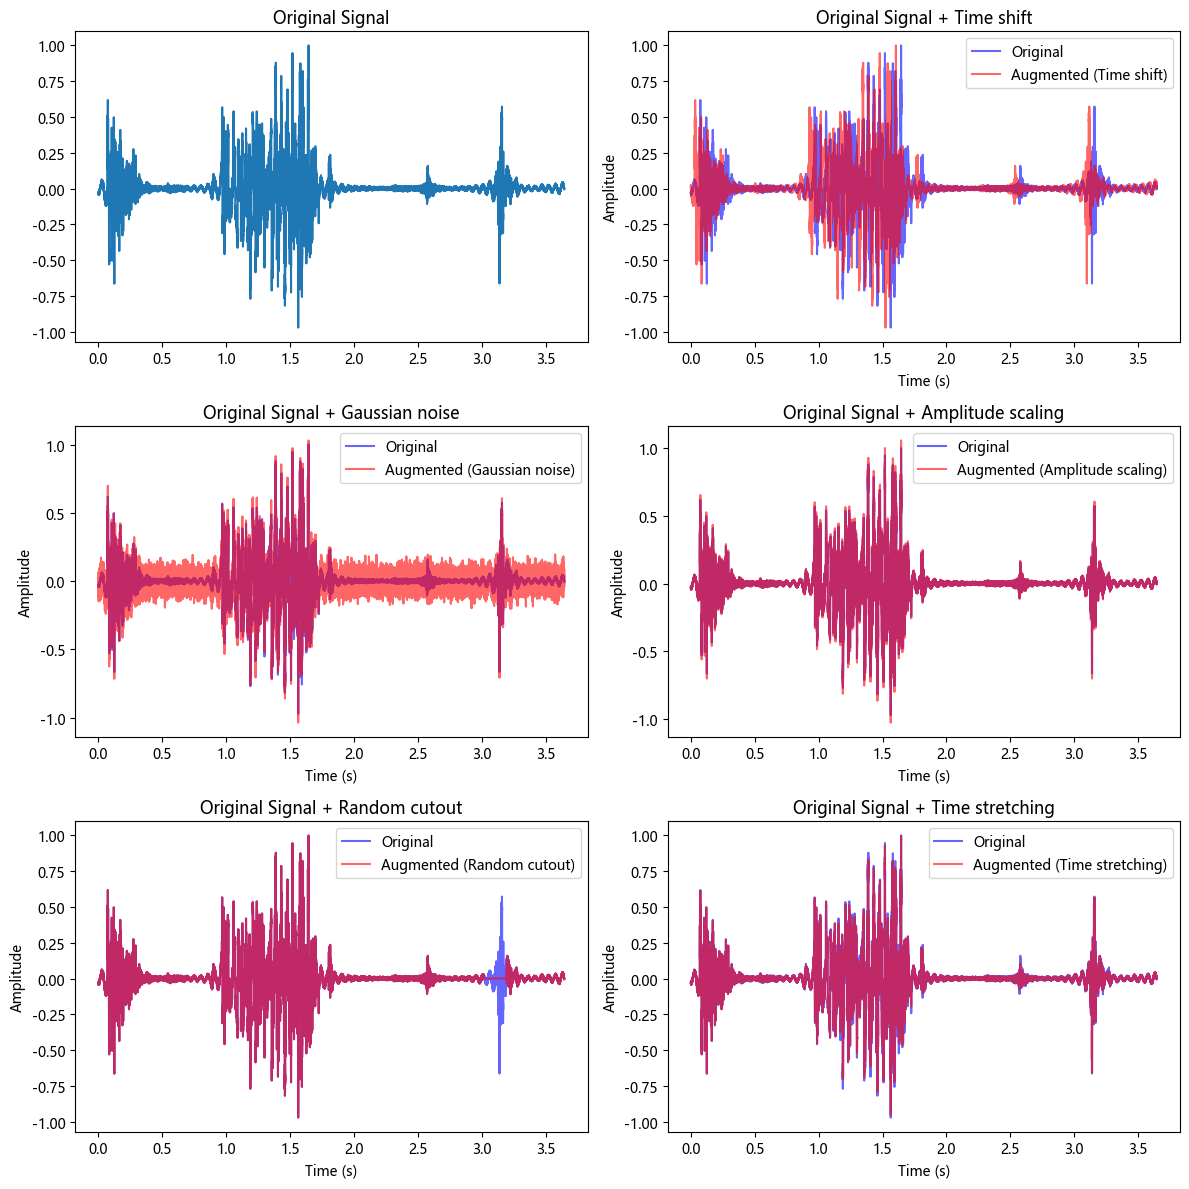

In [5]:
import matplotlib
print(matplotlib.matplotlib_fname())
print(matplotlib.get_cachedir())
import matplotlib.font_manager as fm

font_path = "/home/zhang/anaconda3/envs/zxc_das/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/MicrosoftYaHei.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['font.size'] = '10'
# ========== 展示单个增强方法的效果 ==========
methods = {
    'Time shift': time_shift,
    'Gaussian noise': add_noise,
    'Amplitude scaling': amplitude_scaling,
    'Random cutout': random_cutout,
    'Time stretching': time_stretch
}

plt.figure(figsize=(12, 12))
plt.subplot(3, 2, 1)
taxis = np.arange(len(phase)) / FREQUENCY
plt.plot(taxis, phase)
plt.title('Original Signal')

# 单独画每种增强方法后的结果
for idx, (name, func) in enumerate(methods.items()):
    augmented = func(phase.copy())
    taxis_aug = np.arange(len(augmented)) / FREQUENCY

    plt.subplot(3, 2, idx+2)
    plt.plot(taxis, phase, color='blue', alpha=0.6, label='Original')  # 原始
    plt.plot(taxis_aug, augmented, color='red', alpha=0.6, label=f'Augmented ({name})')  # 增强后
    plt.title(f'Original Signal + {name}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()

plt.tight_layout()
plt.savefig('/home/zhang/zxc/STFT_3DDL/paper/images/augmented.pdf', format='pdf')
plt.show()


/home/zhang/anaconda3/envs/zxc_das/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc
/home/zhang/.cache/matplotlib


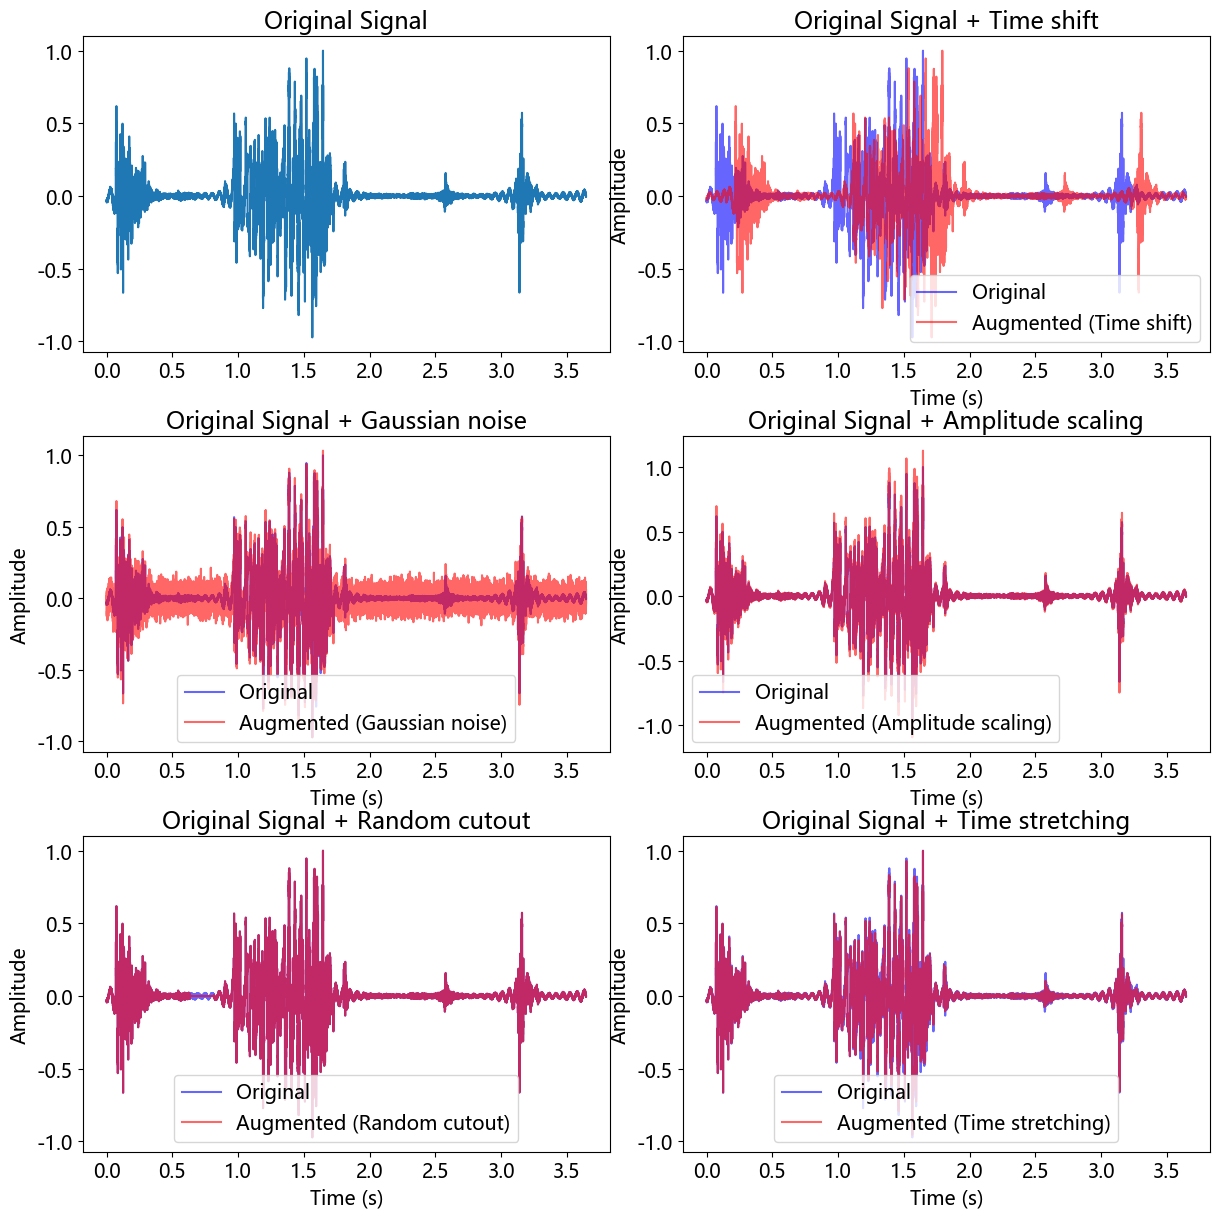

In [6]:

import matplotlib
print(matplotlib.matplotlib_fname())
print(matplotlib.get_cachedir())
import matplotlib.font_manager as fm

font_path = "/home/zhang/anaconda3/envs/zxc_das/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/MicrosoftYaHei.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['font.size'] = '14'
# ========== 展示单个增强方法的效果 ==========
methods = {
    'Time shift': time_shift,
    'Gaussian noise': add_noise,
    'Amplitude scaling': amplitude_scaling,
    'Random cutout': random_cutout,
    'Time stretching': time_stretch
}

plt.figure(figsize=(12, 12))
plt.subplot(3, 2, 1)
taxis = np.arange(len(phase)) / FREQUENCY
plt.plot(taxis, phase)
plt.title('Original Signal')

# 单独画每种增强方法后的结果
for idx, (name, func) in enumerate(methods.items()):
    augmented = func(phase.copy())
    taxis_aug = np.arange(len(augmented)) / FREQUENCY

    plt.subplot(3, 2, idx+2)
    plt.plot(taxis, phase, color='blue', alpha=0.6, label='Original')  # 原始
    plt.plot(taxis_aug, augmented, color='red', alpha=0.6, label=f'Augmented ({name})')  # 增强后
    plt.title(f'Original Signal + {name}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()

plt.tight_layout(pad=0)
plt.savefig('/home/zhang/zxc/STFT_3DDL/paper/images/augmented.pdf', format='pdf', pad_inches=0)
plt.show()


/home/zhang/anaconda3/envs/zxc_das/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc
/home/zhang/.cache/matplotlib


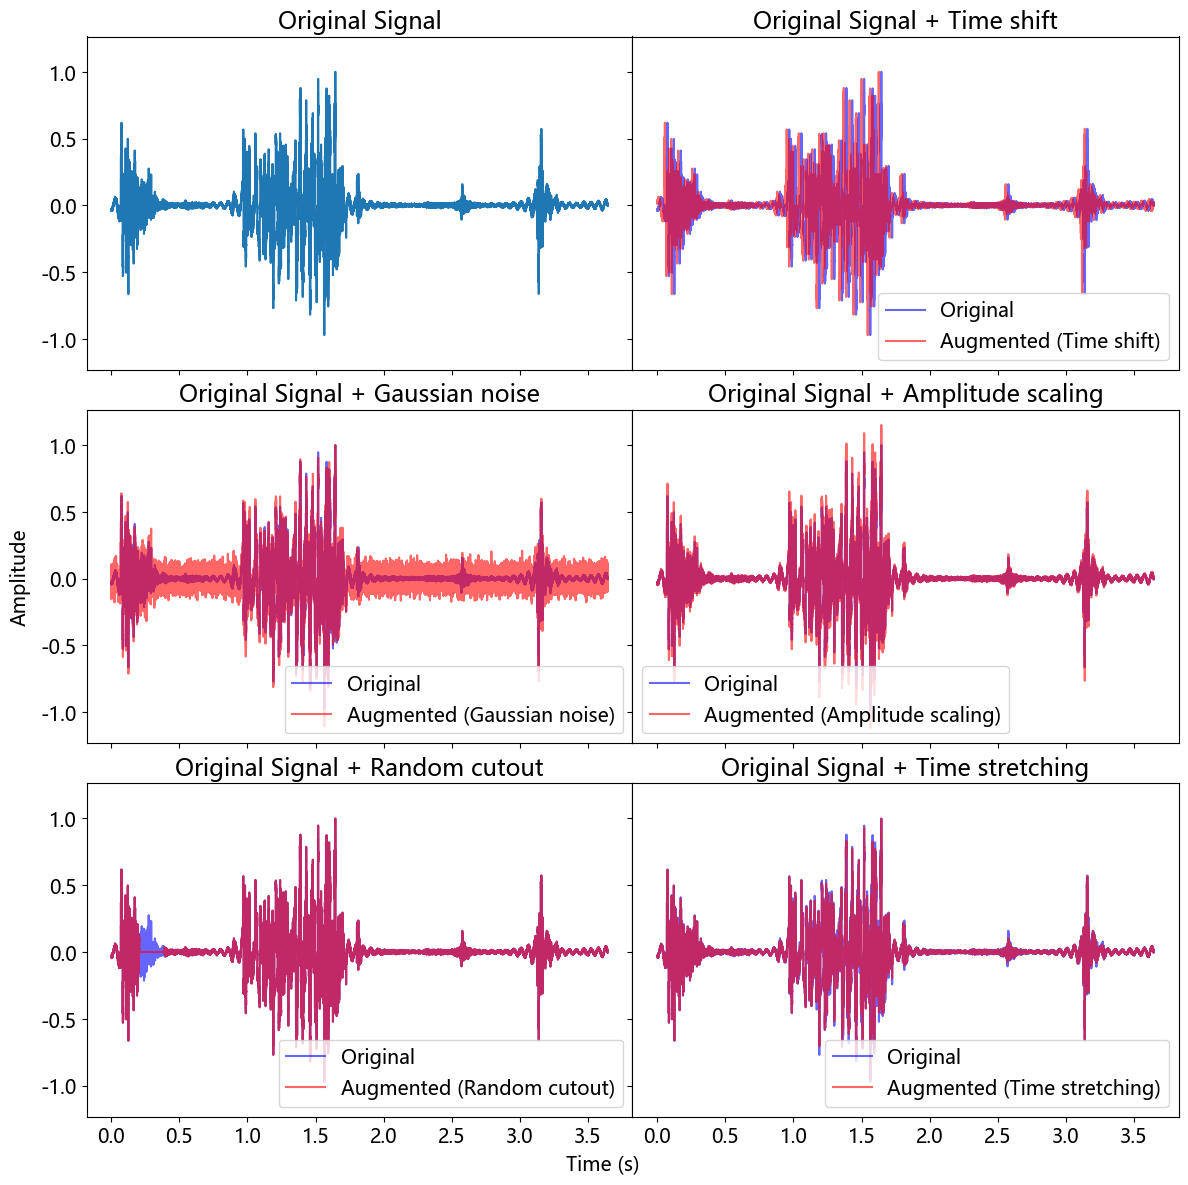

In [7]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

print(matplotlib.matplotlib_fname())
print(matplotlib.get_cachedir())
import matplotlib.font_manager as fm

font_path = "/home/zhang/anaconda3/envs/zxc_das/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/MicrosoftYaHei.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['font.size'] = 14

# ========== 展示单个增强方法的效果 ==========
methods = {
    'Time shift': time_shift,
    'Gaussian noise': add_noise,
    'Amplitude scaling': amplitude_scaling,
    'Random cutout': random_cutout,
    'Time stretching': time_stretch
}

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

taxis = np.arange(len(phase)) / FREQUENCY
axes[0].plot(taxis, phase)
axes[0].set_title('Original Signal')

for idx, (name, func) in enumerate(methods.items()):
    augmented = func(phase.copy())
    taxis_aug = np.arange(len(augmented)) / FREQUENCY

    ax = axes[idx + 1]
    ax.plot(taxis, phase, color='blue', alpha=0.6, label='Original')
    ax.plot(taxis_aug, augmented, color='red', alpha=0.6, label=f'Augmented ({name})')
    ax.set_title(f'Original Signal + {name}')
    ax.legend()

# 设置统一的 x/y label 位置
fig.text(0.5, 0.01, 'Time (s)', ha='center', va='center')
fig.text(0.015, 0.5, 'Amplitude', ha='center', va='center', rotation='vertical')

# 移除单个子图的 xlabel、ylabel
for ax in axes:
    ax.label_outer()  # 只保留最外侧的 tick label，去掉中间的

# 用 subplots_adjust 增加画布边缘留白（重点！）
plt.subplots_adjust(left=0.07, bottom=0.05, right=0.98, top=0.95, wspace=0, hspace=0.12)

# # plt.tight_layout(pad=0)
# plt.tight_layout(w_pad=0.1)
# plt.savefig('/home/zhang/zxc/STFT_3DDL/paper/images/augmented.pdf', format='pdf', pad_inches='tight')
plt.show()


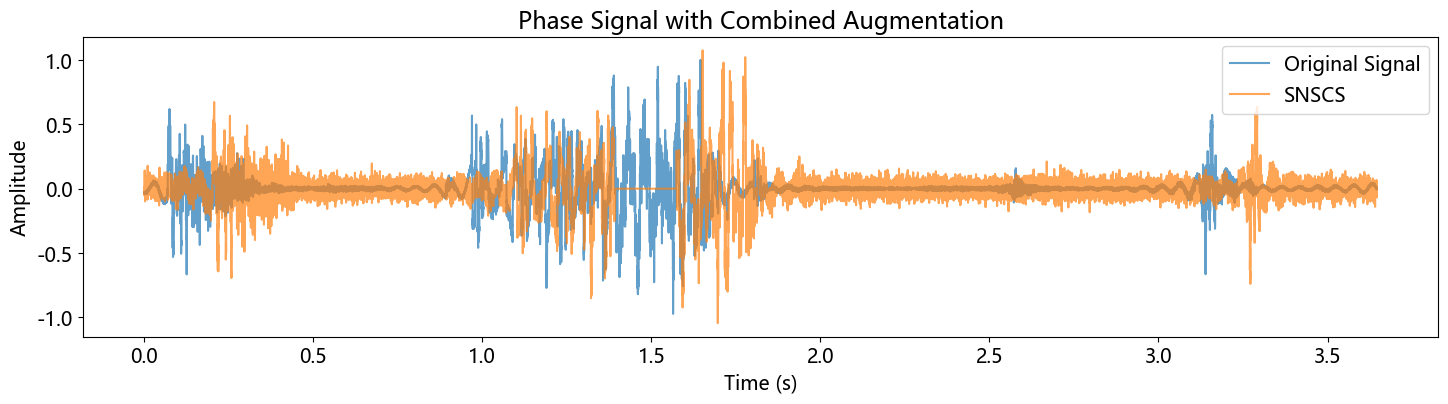

In [9]:
# ========== 展示叠加增强方法的效果 ==========
# 举例：叠加 shift -> noise -> cutout
phase_aug = phase.copy()
for name in ['Time shift', 'Gaussian noise', 'Random cutout', 'Time stretching', 'Amplitude scaling']:
    phase_aug = methods[name](phase_aug)

intensity_aug = intensity.copy()
for name in ['Time shift', 'Gaussian noise', 'Random cutout', 'Time stretching', 'Amplitude scaling']:
    intensity_aug = methods[name](intensity_aug)

plt.figure(figsize=(14.5, 4))
taxis_aug = np.arange(len(phase_aug)) / FREQUENCY
plt.plot(taxis, phase, label='Original Signal', alpha=0.7)
plt.plot(taxis_aug, phase_aug, label='SNSCS', alpha=0.7)
plt.title('Phase Signal with Combined Augmentation')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()

# 用 subplots_adjust 增加画布边缘留白（重点！）
plt.subplots_adjust(left=0.055, bottom=0.15, right=0.99, top=0.9)

# plt.savefig('/home/zhang/zxc/STFT_3DDL/paper/images/SNSCS.pdf', format='pdf', pad_inches='tight')
plt.show()
# print_signal(phase_aug, FREQUENCY)
# print_signal(intensity_aug, FREQUENCY)

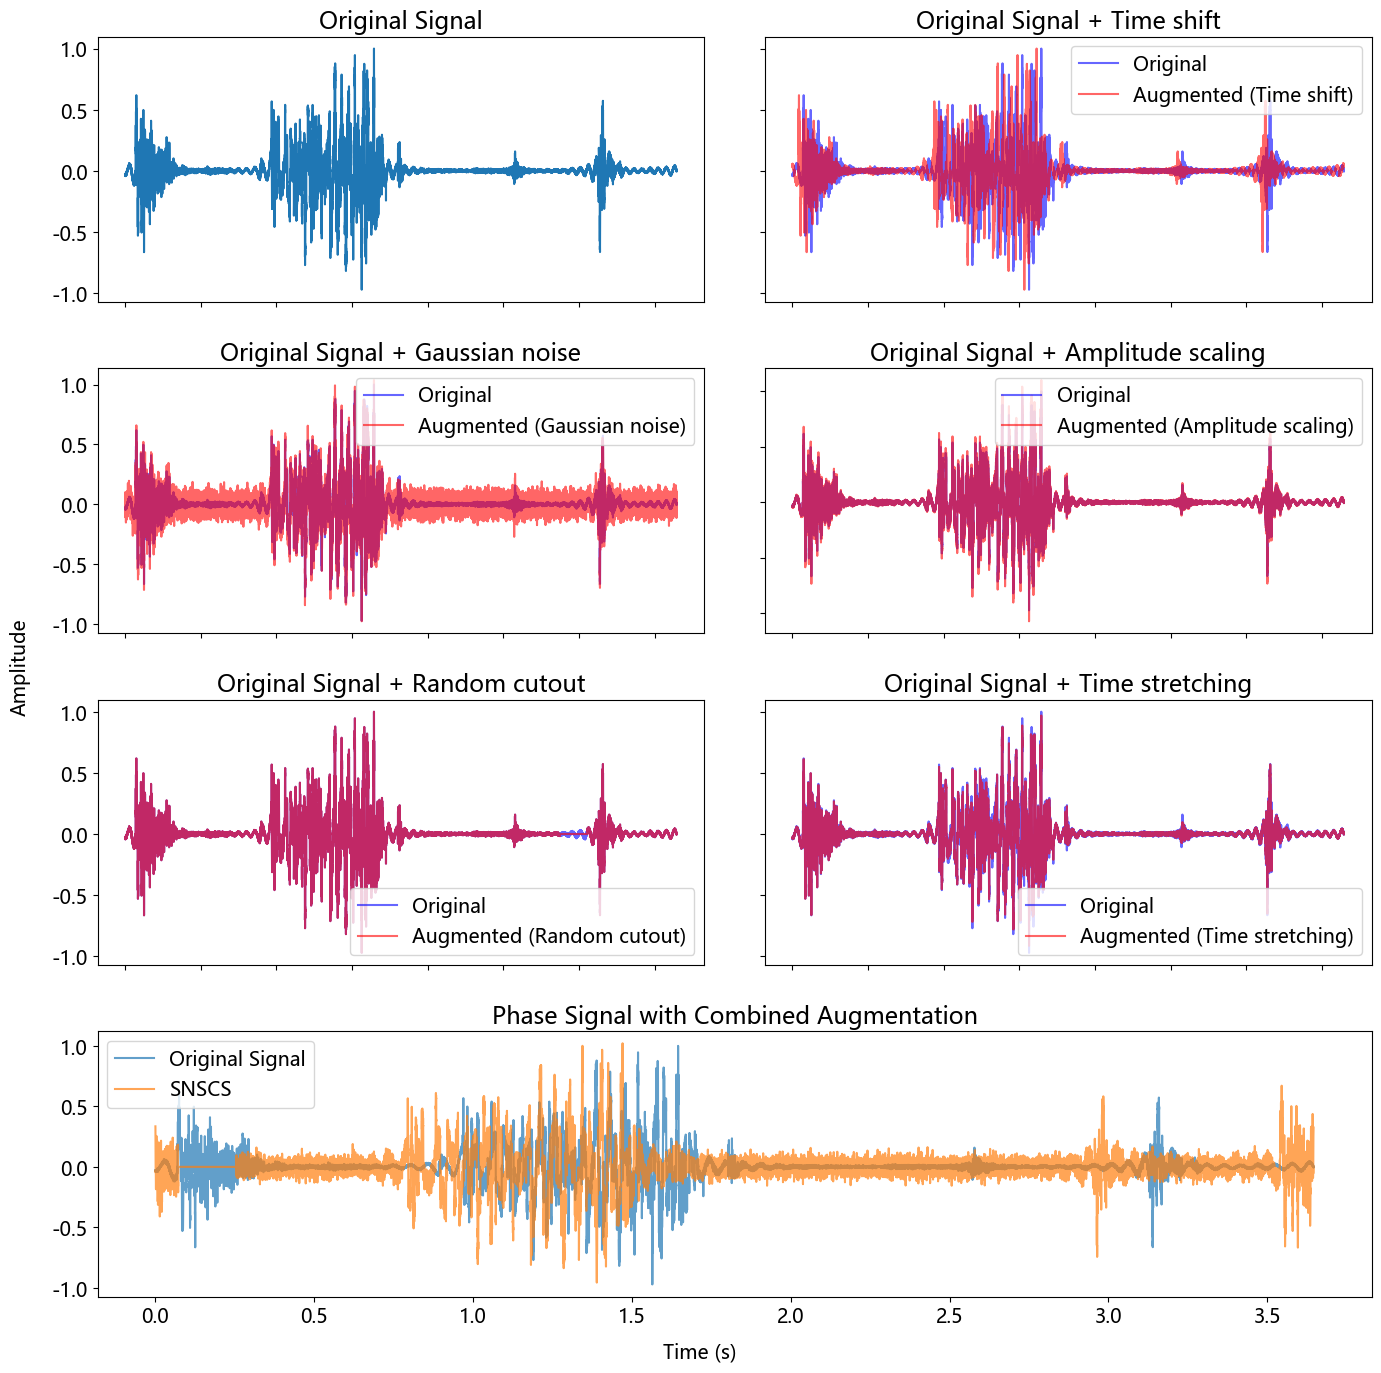

In [12]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec

# 设置字体
font_path = "/home/zhang/anaconda3/envs/zxc_das/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/MicrosoftYaHei.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['font.size'] = 14

# ========== 假设已有如下 ==========
# phase, intensity, FREQUENCY
# time_shift, add_noise, amplitude_scaling, random_cutout, time_stretch

methods = {
    'Time shift': time_shift,
    'Gaussian noise': add_noise,
    'Amplitude scaling': amplitude_scaling,
    'Random cutout': random_cutout,
    'Time stretching': time_stretch
}

# 使用 gridspec 来灵活布局
fig = plt.figure(figsize=(14, 14))
gs = gridspec.GridSpec(4, 2, figure=fig)

# 子图列表
axes = []

# 原始信号图（第1行左上角）
taxis = np.arange(len(phase)) / FREQUENCY
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(taxis, phase)
ax0.set_title('Original Signal')
axes.append(ax0)

# 5个增强图（依次填入剩余5格）
for i, (name, func) in enumerate(methods.items()):
    row = (i + 1) // 2
    col = (i + 1) % 2
    ax = fig.add_subplot(gs[row, col])
    augmented = func(phase.copy())
    taxis_aug = np.arange(len(augmented)) / FREQUENCY
    ax.plot(taxis, phase, color='blue', alpha=0.6, label='Original')
    ax.plot(taxis_aug, augmented, color='red', alpha=0.6, label=f'Augmented ({name})')
    ax.set_title(f'Original Signal + {name}')
    ax.legend()
    axes.append(ax)

# 最后一图占两列（第4行整行）
phase_aug = phase.copy()
intensity_aug = intensity.copy()
for name in methods:
    phase_aug = methods[name](phase_aug)
    intensity_aug = methods[name](intensity_aug)

taxis_aug = np.arange(len(phase_aug)) / FREQUENCY
ax_combined = fig.add_subplot(gs[3, :])  # 跨两列
ax_combined.plot(taxis, phase, label='Original Signal', alpha=0.7)
ax_combined.plot(taxis_aug, phase_aug, label='SNSCS', alpha=0.7)
ax_combined.set_title('Phase Signal with Combined Augmentation')
ax_combined.legend()
axes.append(ax_combined)

# 设置统一标签
fig.text(0.5, 0.01, 'Time (s)', ha='center', va='center')
fig.text(0.015, 0.5, 'Amplitude', ha='center', va='center', rotation='vertical')

# 去除内侧坐标标签
for ax in axes:
    ax.label_outer()

# 调整间距
plt.subplots_adjust(left=0.07, bottom=0.05, right=0.98, top=0.95, wspace=0.1, hspace=0.25)

# 保存或展示
plt.savefig('/home/zhang/zxc/STFT_3DDL/paper/images/augmented+SNSCS.pdf', format='pdf', pad_inches='tight')
plt.show()


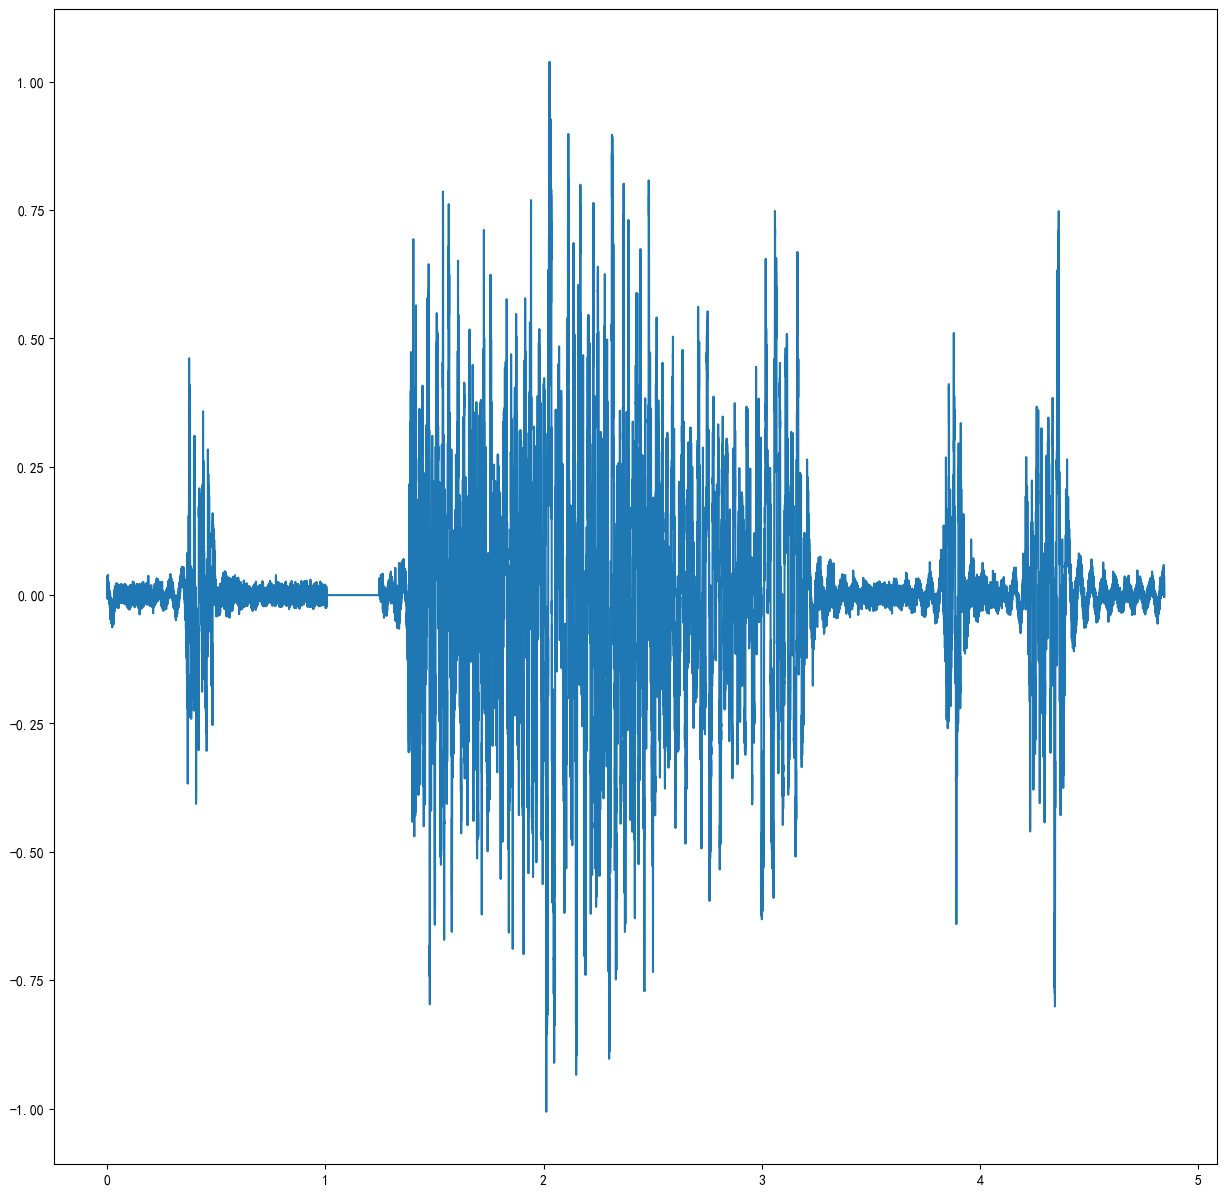

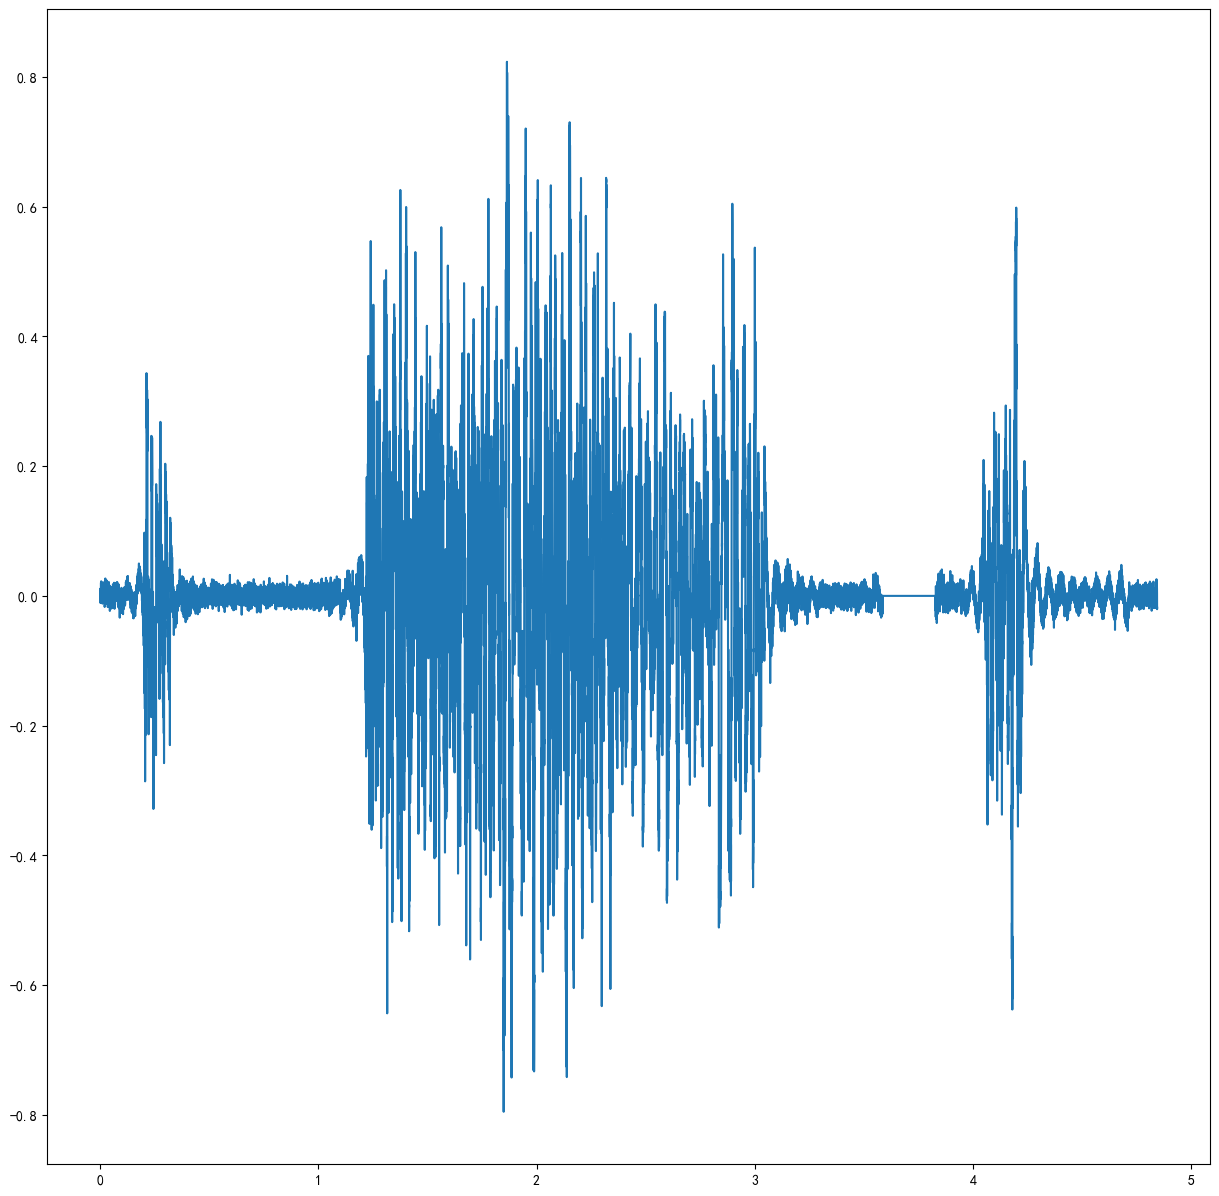

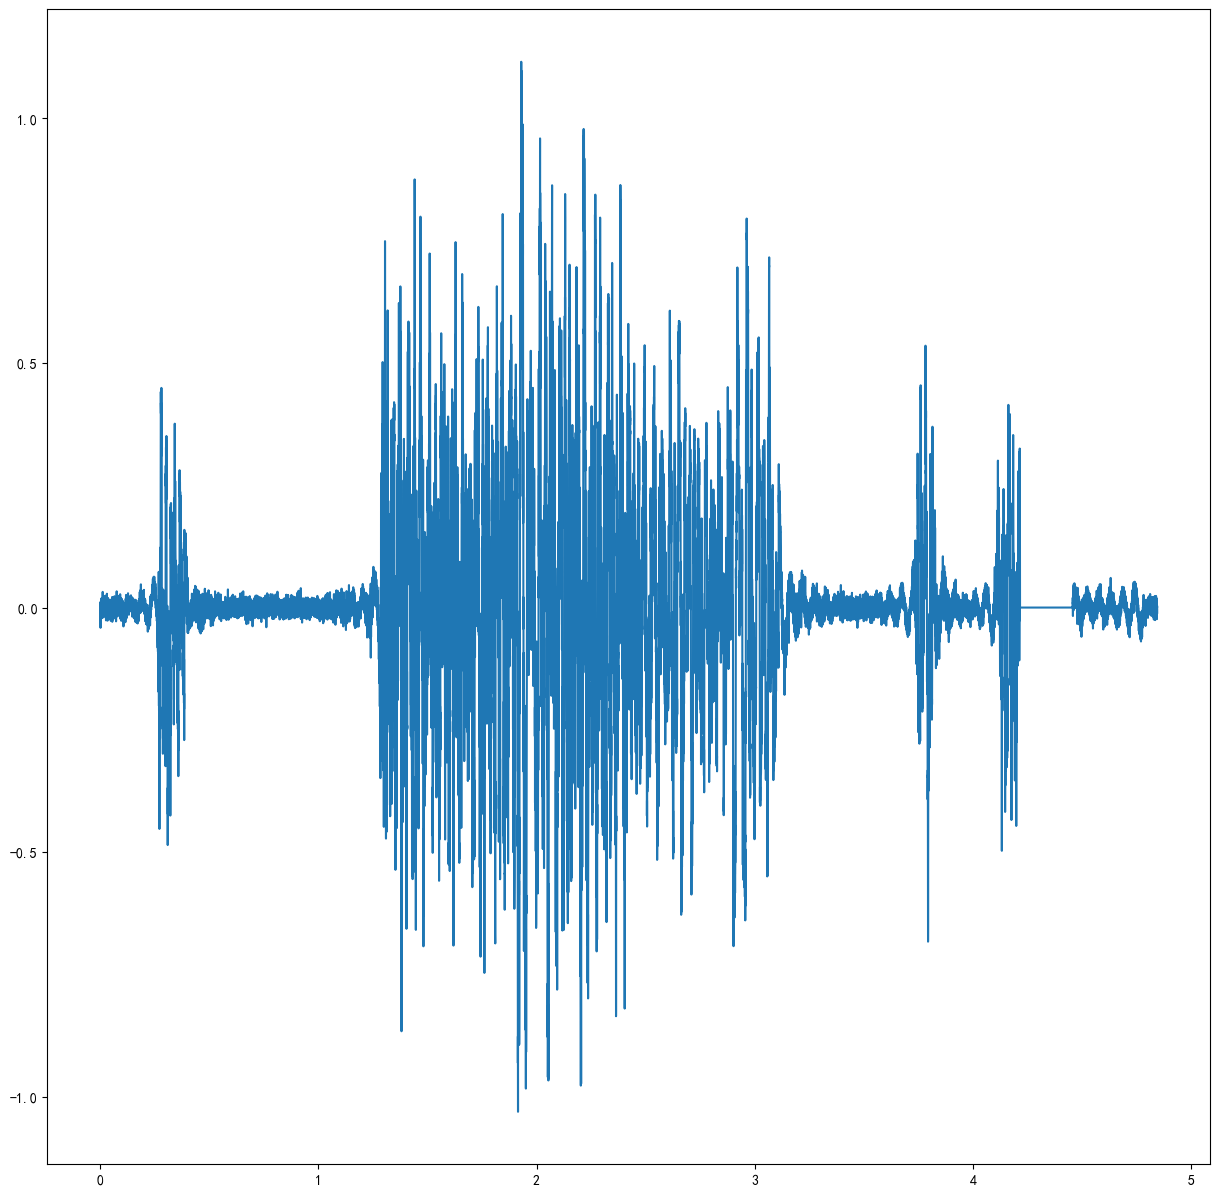

In [ ]:
# 测试生成的3个混合数据增强样本是否一样
signal_file1 = "/home/zhang/zxc/STFT_3DDL/DATASETS/raw_data/DAS1K_shift_noise_scale_cutout_stretch/CARHORN/carhorn7_0.mat"
signal_file2 = "/home/zhang/zxc/STFT_3DDL/DATASETS/raw_data/DAS1K_shift_noise_scale_cutout_stretch/CARHORN/carhorn7_1.mat"
signal_file3 = "/home/zhang/zxc/STFT_3DDL/DATASETS/raw_data/DAS1K_shift_noise_scale_cutout_stretch/CARHORN/carhorn7_2.mat"

mat1 = loadmat(str(signal_file1))
phase1 = mat1['carhorn7_0'][0]

mat2 = loadmat(str(signal_file2))
phase2 = mat2['carhorn7_1'][0]

mat3 = loadmat(str(signal_file3))
phase3 = mat3['carhorn7_2'][0]

print_signal(phase1, FREQUENCY)
print_signal(phase2, FREQUENCY)
print_signal(phase3, FREQUENCY)